In [42]:
!python -m pip install -r requirements.txt
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.cluster import KMeans
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

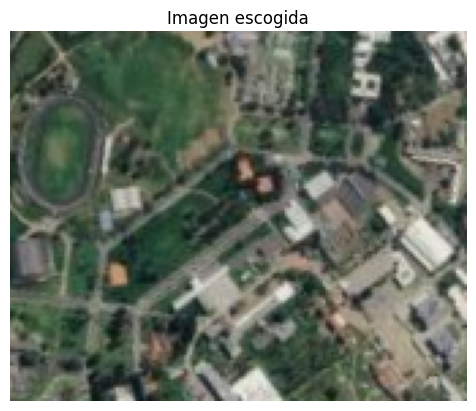

In [93]:
image = cv2.imread('image.png')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

r = cv2.selectROI("Selecciona ROI", cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR), fromCenter=False)
cv2.destroyAllWindows()

roi = image_rgb[int(r[1]):int(r[1]+r[3]), int(r[0]):int(r[0]+r[2])]

plt.title("Imagen escogida")
plt.axis("off")
plt.imshow(roi)
plt.show()

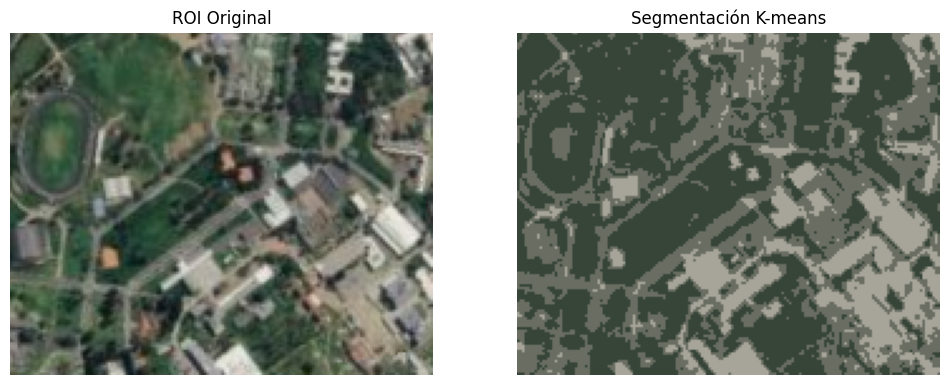

In [ ]:
n_clusters = 3
pixels = roi.reshape((-1, 3))

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(pixels)
segmented_labels = kmeans.labels_.reshape(roi.shape[:2])
centers = kmeans.cluster_centers_

segmented_colored = np.zeros_like(roi)
for i in range(n_clusters):
    segmented_colored[segmented_labels == i] = centers[i]
    
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(roi)
ax[0].set_title("ROI Original")
ax[0].axis('off')

ax[1].imshow(segmented_colored)
ax[1].set_title("Segmentación K-means")
ax[1].axis('off')
plt.show()

In [88]:
pickers = []
n_lbl = int(input("Ingrese un número de etiquetas a crear: "))
for i in range(n_lbl):
    text = widgets.Label(value=f"Nombre y color de etiqueta {i+1}:")
    color_picker = widgets.ColorPicker(
        concise=True,
        value='blue',
        disabled=False
    )
    label = widgets.Text()
    display(widgets.HBox([text, label, color_picker]))
    pickers.append((color_picker, label))

In [117]:
int24_to_rgb = lambda x: np.uint8([x//(256*256), (x//256) % 256, x % 256])
hex_to_rgb = lambda x: int24_to_rgb(int(x.lstrip("#"),16))
center_to_label = {}
for i,v in enumerate(centers):
    closest = pickers[0][1].value
    # cls_c = hex_to_rgb(pickers[0][0].value)
    min_dist = np.linalg.norm(hex_to_rgb(pickers[0][0].value) - v)
    for col, lbl in pickers[1:]:
        rgb = hex_to_rgb(col.value)
        if (dist:=np.linalg.norm(rgb - v)) < min_dist:
            min_dist = dist
            closest = lbl.value
            # cls_c = rgb
    center_to_label[i] = closest
    print(f"El centroide {i+1} se acerca más a la etiquetea \"{closest}\"")
    # print(closest, v, cls_c, np.linalg.norm(cls_c - v))
# print(center_to_label)

El centroide 1 se acerca más a la etiquetea "Caminos"
El centroide 2 se acerca más a la etiquetea "Edificios"
El centroide 3 se acerca más a la etiquetea "Vegetación"


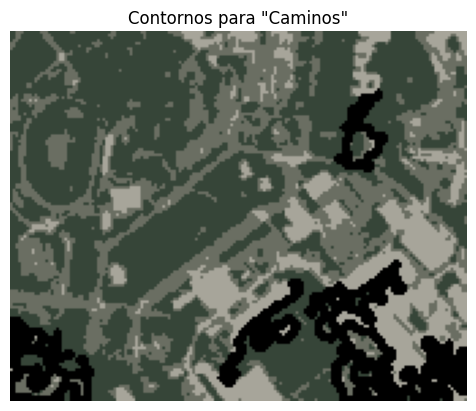

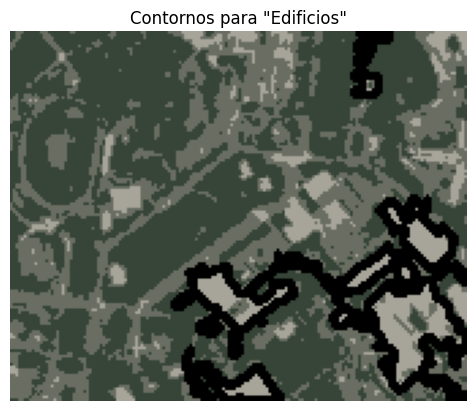

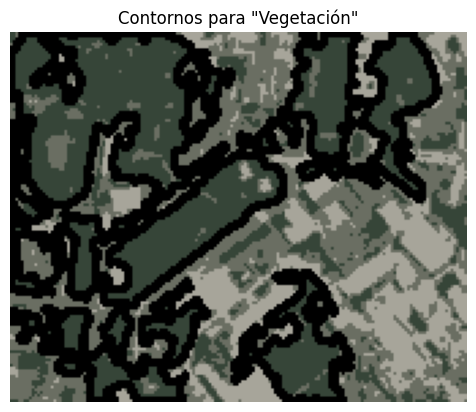

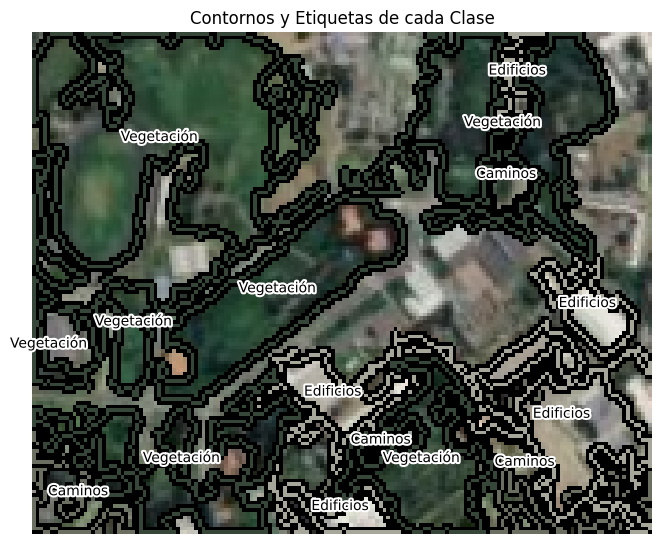

In [132]:
roi_contours = roi.copy()
text = []

for i in range(n_clusters):
    binary_mask = np.uint8(segmented_labels == i) * 255

    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    min_area = 100
    max_area = roi.size / 10
    filtered_contours = [c for c in contours if  max_area > cv2.contourArea(c) > min_area]

    cv2.drawContours(roi_contours, filtered_contours, -1, (0,0,0), 2)
    cv2.drawContours(roi_contours, filtered_contours, -1, centers[i], 1)

    bin_contours = segmented_colored.copy() #cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)
    cv2.drawContours(bin_contours, filtered_contours, -1, (0, 0, 0), 2)
    plt.axis("off")
    plt.title(f"Contornos para \"{center_to_label[i]}\"")
    plt.imshow(bin_contours, cmap="gray")
    plt.show()

    for _, c in enumerate(filtered_contours):
        M = cv2.moments(c)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            text.append((center_to_label[i], cX, cY))
        else:
            text.append((f"Zona {_+1}", cX, cY))
            

plt.figure(figsize=(8, 8))
plt.imshow(roi_contours)
for t, x, y in text:
    txt = plt.text(x, y, t, ha="center")
    txt.set_path_effects([
        path_effects.withStroke(linewidth=3, foreground="white")
    ])
plt.title(f"Contornos y Etiquetas de cada Clase")
plt.axis('off')
plt.show()